# Metacatalog query browser

Browse Parquet catalogs under any discovered catalog tree under `CATALOG_ROOT`
(per-hour sources, LST-merged bands, and the global metacatalog). Use the
**Catalog directory** selector to switch trees, then pick a Parquet file and a
**HiPS survey** for the sky view. Inspect tables in a sortable/filterable grid,
find the nearest source to a sky coordinate, and — when viewing the
**metacatalog** — click a row to rematch that `meta_id` into LST/sources members
with consistency plots. Row clicks update the nearest-source coordinate box.
The first table row is selected with a **HiPS** overlay by default (refreshes on pan/zoom).
Enable **Pick nearest on sky click** to select a `meta_id` from the sky view (nearest
in-FOV source to the click). Plot per-band spectral flux and the stored Taylor model
for the selected row.

Optional config filters (config cell): `QUALITY_FLAG_MASK` (bitmask) and
`RADIO_QA_FILTER` (boolean Series / Index / labels / pandas query string). A string
seeds the browser **RADIO_QA_FILTER** box — edit and **Apply filter** without reloading
(e.g. `n_assoc_NVSS >= 1` when browsing `metacatalog_radio.parquet`).

Launch with `jupyter lab` (or your usual kernel that has `lwa-catalog[viz]`).
**Run cells in order.**


In [1]:
from __future__ import annotations

import json
import re
from pathlib import Path

import astropy.units as u
import numpy as np
import pandas as pd
import panel as pn
import param
from astropy.coordinates import SkyCoord

from lwa_catalog.analyze import filter_by_quality_mask, gather_band_flux_measurements
from lwa_catalog.analyze.spectral import SingleSpectrumFit, evaluate_taylor_spectrum
from lwa_catalog.constants import SUBBAND_BANDS_MHZ, SUBBAND_REF_FREQ_MHZ
from lwa_catalog.io import read_metacatalog, read_table
from lwa_catalog.paths import CatalogLayout
from lwa_catalog.viz import (
    DebouncedAladinViewRefresh,
    aladin_view_center_fov,
    catalog_name_from_file,
    clear_catalog_overlays,
    clear_trace_overlays,
    default_hips_survey,
    discover_local_hips_surveys,
    fetch_hips_surveys,
    filter_catalog_fov,
    format_coordinate_deg,
    hips_survey_url,
    overlay_catalog_by_band,
    parse_coordinate,
)

# --- user configuration ---------------------------------------------------
CATALOG_ROOT = Path("/fast/claw")
DEFAULT_CATALOG_DIR = Path("/fast/claw/metacatalog_coaddR-0.75_subband")


def discover_catalog_dirs(root: Path, *, pattern: str = "metacatalog*") -> list[Path]:
    """Discover catalog trees under *root* that contain at least one Parquet file."""
    if not root.is_dir():
        return []
    return sorted(
        p.resolve()
        for p in root.glob(pattern)
        if p.is_dir() and any(p.glob("*.parquet"))
    )


CATALOG_DIRS = discover_catalog_dirs(CATALOG_ROOT)
_default = DEFAULT_CATALOG_DIR.resolve()
if _default not in CATALOG_DIRS:
    CATALOG_DIRS = sorted({_default, *CATALOG_DIRS})
DEFAULT_CATALOG_DIR = _default if _default in CATALOG_DIRS else CATALOG_DIRS[0]

# HiPS tiles load in your web browser (not the Jupyter kernel).
# HIPS_LIST_SERVER — survey names from ``cgi-bin/list-hips.py`` (dropdown; kernel fetch).
# HIPS_SERVER — tile base URL passed to Aladin (browser fetch; can differ from list host).
# If the list fetch fails, scans the selected catalog directory for HiPS ``properties`` dirs.
# Example: list from pipeline, serve coadd tiles locally:
#   ssh -L 3005:lwacalim10:3005 lwacalim09
#   python -m http.server 8000 --directory /fast/claw/metacatalog_coadd2
#   HIPS_LIST_SERVER = "http://localhost:3005"
#   HIPS_SERVER = "http://localhost:8000"
HIPS_LIST_SERVER = "http://lwacalim10:3005"  # or http://localhost:3005 when SSH-tunneled
HIPS_SERVER = "http://localhost:3005"
DEFAULT_HIPS_SURVEY = (
    "Blue_I_deep_Taper_Robust-0.75_pbcorr_coadd_mosaic_jysr_feather_allsky_20241218-20250823_N023.hips"
)
SKY_FOV_DEG = 10
HIPS_VIEW_HEIGHT = 500
OVERLAY_MAX_SOURCES_DEFAULT = 500
OVERLAY_MAX_SOURCES_BOUNDS = (100, 1000)

TABLE_HEIGHT = 420
TABLE_PAGE_SIZE = 50
DEFAULT_N_NEAREST = 3
MAX_TABLE_COLUMNS = 40  # keep Tabulator responsive for wide metacatalog rows

# Default metacatalog row filter (quality_flag & 33267 == 0); no-op when quality_flag is absent.
# Bits: HAS_NAN|INVALID_ASTROMETRY|UNPHYSICAL_FLUX|RESID_ABS_FAIL|RESID_PCTL_RMS|RESID_PCTL_MEAN|JITTER_FAIL|LARGE_SINGLE
QUALITY_FLAG_MASK = 33267  # set None to keep all rows

# Optional row subset after quality mask (useful for metacatalog_radio.parquet).
# None | boolean Series aligned to index | Index | label array | pandas query string.
# A string seeds the CatalogBrowser text box; edit/apply it interactively without reloading.
# Examples:
# RADIO_QA_FILTER = None
# RADIO_QA_FILTER = "n_assoc_NVSS >= 1"
# RADIO_QA_FILTER = "n_assoc_VLASS >= 1 and Total_flux_NVSS > 0.05"
# RADIO_QA_FILTER = "spec_model_chi2_red < 2"
RADIO_QA_FILTER = None


def load_metacatalog_frame(
    layout: CatalogLayout,
    *,
    prefer_spectral: bool = True,
    prefer_quality: bool = True,
) -> pd.DataFrame:
    """Read the preferred metacatalog Parquet and apply ``QUALITY_FLAG_MASK`` by default."""
    return read_metacatalog(
        layout,
        prefer_spectral=prefer_spectral,
        prefer_quality=prefer_quality,
        quality_mask=QUALITY_FLAG_MASK,
    )


def apply_quality_mask_if_configured(df: pd.DataFrame) -> pd.DataFrame:
    """Apply the default quality bitmask when enabled and ``quality_flag`` is present."""
    if QUALITY_FLAG_MASK is None:
        return df
    return filter_by_quality_mask(df, QUALITY_FLAG_MASK)


def apply_radio_qa_filter(
    df: pd.DataFrame,
    row_filter: pd.Series | pd.Index | np.ndarray | list | str | None,
) -> pd.DataFrame:
    """Subset *df* with a pandas boolean mask, Index, label array, or query string."""
    if row_filter is None:
        return df.copy()
    if isinstance(row_filter, str):
        return df.query(row_filter).copy()
    if isinstance(row_filter, pd.Series):
        if not pd.api.types.is_bool_dtype(row_filter):
            raise TypeError("RADIO_QA_FILTER Series must be boolean")
        aligned = row_filter.reindex(df.index)
        if aligned.isna().any():
            missing = int(aligned.isna().sum())
            raise ValueError(
                f"RADIO_QA_FILTER boolean Series has {missing} index labels "
                "not present in the catalog"
            )
        return df.loc[aligned.astype(bool)].copy()
    if isinstance(row_filter, pd.Index):
        missing = row_filter.difference(df.index)
        if len(missing):
            raise ValueError(
                f"RADIO_QA_FILTER Index has {len(missing)} labels not in the catalog"
            )
        return df.loc[row_filter].copy()
    labels = pd.Index(row_filter)
    missing = labels.difference(df.index)
    if len(missing):
        raise ValueError(
            f"RADIO_QA_FILTER labels have {len(missing)} entries not in the catalog"
        )
    return df.loc[labels].copy()


def apply_catalog_row_filters(df: pd.DataFrame) -> pd.DataFrame:
    """Apply ``QUALITY_FLAG_MASK`` only.

    ``RADIO_QA_FILTER`` is applied by ``CatalogBrowser`` (interactive string box, or
    a non-string config value on first publish).
    """
    return apply_quality_mask_if_configured(df)

# Preferred column order when present (others follow alphabetically).
# Overridden at runtime by DISPLAY_COLUMN_PREFS if that file exists.
PREFERRED_COLUMNS = (
    "meta_id",
    "Source_id",
    "RA",
    "DEC",
    "Peak_flux",
    "Total_flux",
    "band",
    "lst_hour",
    "bands_present",
    "origin_band",
    "n_lst_contributions",
    "source_file",
)

DISPLAY_COLUMN_PREFS = Path.home() / ".config" / "lwa-catalog" / "metacatalog_query_columns.json"


def load_display_column_prefs(path: Path = DISPLAY_COLUMN_PREFS) -> list[str]:
    """Load saved display-column preference, else fall back to PREFERRED_COLUMNS."""
    try:
        raw = json.loads(path.read_text())
        cols = [str(c) for c in raw.get("columns", []) if str(c).strip()]
        if cols:
            return cols
    except (OSError, json.JSONDecodeError, AttributeError, TypeError):
        pass
    return list(PREFERRED_COLUMNS)


def save_display_column_prefs(columns: list[str], path: Path = DISPLAY_COLUMN_PREFS) -> Path:
    """Persist display-column preference for later notebook sessions."""
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps({"columns": list(columns)}, indent=2) + "\n")
    return path


# Mutable default used by the browser (seeded from prefs file or PREFERRED_COLUMNS)
_preferred_columns: list[str] = load_display_column_prefs()


SPEC_COLUMN_PREFIX = "spec_"
SPEC_REF_FREQ_MHZ = SUBBAND_REF_FREQ_MHZ

pn.extension("tabulator", throttled=True)


## Available catalog files

Inventory of every `*.parquet` under the default catalog tree (`DEFAULT_CATALOG_DIR`),
classified by artifact kind. The inventory table below refreshes when you change
**Catalog directory** in the browser.


In [2]:
_SOURCES_RE = re.compile(r"^sources_(?P<lst>\d+h)_(?P<band>Full|Blue|Green|Red)\.parquet$")
_LST_RE = re.compile(r"^metacatalog_lst_(?P<band>Full|Blue|Green|Red)\.parquet$")


_METACATALOG_RE = re.compile(
    r"^metacatalog(?:_[^/]+)?\.parquet$",
    re.IGNORECASE,
)


def is_metacatalog_parquet(name: str) -> bool:
    """True for ``metacatalog.parquet`` and derived ``metacatalog_*.parquet`` tables."""
    return bool(_METACATALOG_RE.match(name)) and not name.startswith("metacatalog_lst_")


def classify_catalog(path: Path) -> dict:
    """Return kind / LST / band metadata for a catalog Parquet path."""
    name = path.name
    m = _LST_RE.match(name)
    if m:
        return {"kind": "lst_merged", "lst_hour": None, "band": m.group("band")}
    if is_metacatalog_parquet(name):
        return {"kind": "metacatalog", "lst_hour": None, "band": None}
    m = _SOURCES_RE.match(name)
    if m:
        return {"kind": "sources", "lst_hour": m.group("lst"), "band": m.group("band")}
    return {"kind": "other", "lst_hour": None, "band": None}


def inventory_catalogs(catalog_dir: Path) -> pd.DataFrame:
    """List Parquet catalogs with size and row counts (metadata only)."""
    rows: list[dict] = []
    for path in sorted(catalog_dir.glob("*.parquet")):
        meta = classify_catalog(path)
        try:
            import pyarrow.parquet as pq

            n_rows = pq.ParquetFile(path).metadata.num_rows
        except Exception:
            n_rows = None
        rows.append(
            {
                "file": path.name,
                "kind": meta["kind"],
                "lst_hour": meta["lst_hour"],
                "band": meta["band"],
                "n_rows": n_rows,
                "size_mb": round(path.stat().st_size / 1e6, 2),
                "path": str(path),
            }
        )
    return pd.DataFrame(rows)


catalog_index = inventory_catalogs(DEFAULT_CATALOG_DIR)
print(f"{len(catalog_index)} Parquet files in {DEFAULT_CATALOG_DIR}")
print(f"Discovered {len(CATALOG_DIRS)} catalog trees under {CATALOG_ROOT}")
print(catalog_index["kind"].value_counts().to_string())

inventory_table = pn.widgets.Tabulator(
    catalog_index.drop(columns=["path"]),
    pagination="local",
    page_size=25,
    height=320,
    sizing_mode="stretch_width",
    layout="fit_data_table",
    header_filters=True,
    show_index=False,
    disabled=True,
    sortable=True,
    selectable=1,
)
inventory_table


352 Parquet files in /fast/claw/metacatalog_coaddR-0.75_subband
Discovered 5 catalog trees under /fast/claw
kind
other          345
metacatalog      7


Tabulator(disabled=True, header_filters=True, height=320, page_size=25, pagination='local', show_index=False, sizing_mode='stretch_width', value=              ...)

## Select a table, browse rows, load sky / trace / nearest

1. Choose a **Catalog directory**, then pick a **Catalog file** (or click a row in the inventory table).
2. Use **Display columns** to choose which fields appear in the browse table.
3. The first browse-table row is selected and its sky overlay loads by default. Use the action buttons below the table:
   - **Load sky view** — center HiPS and draw overlays for the **selected** row of the **selected Parquet only**
   - **Pick nearest on sky click** — click the map to select the nearest in-FOV `meta_id` (updates the browse table; use **Plot spectrum** / **Load trace** as usual)
   - **Load trace** — rematch LST / per-hour sources and update the tables and plots below (does not change the sky overlay)
   - **Load nearest** — find neighbors around the selected row's coordinates
   - **Plot spectrum** (below the sky view) — per-band flux and Taylor model for the selected row
4. Trace, nearest, and spectrum do **not** run automatically on row click (keeps the browser responsive).
5. **Save sky PNG** writes a quick QA screenshot under `<catalog-dir>/sky_screenshots/`.
6. **RADIO_QA_FILTER** (below the load header) accepts a pandas query string — e.g. `n_assoc_NVSS >= 1`. Click **Apply filter** to subset the loaded table (and sky overlay); **Clear** restores all quality-cleared rows without reloading the Parquet.


<IPython.core.display.Javascript object>

CatalogBrowser(band='all', catalog_dir='/fast/claw/metacatalog_coaddR-0.75_subband', catalog_file='metacatalog_quality.parquet', coordinate='68.926554 29.690979', display_columns=['meta_id', 'RA', 'DEC', 'bands_present', 'origin_band', 'n_lst_contributions'], kind='all', lst_hour='all', max_sources=500, meta_id=1035, n_nearest=3, name='CatalogBrowser00124', pick_on_click=False, radio_qa_filter='', show_overlay=True)
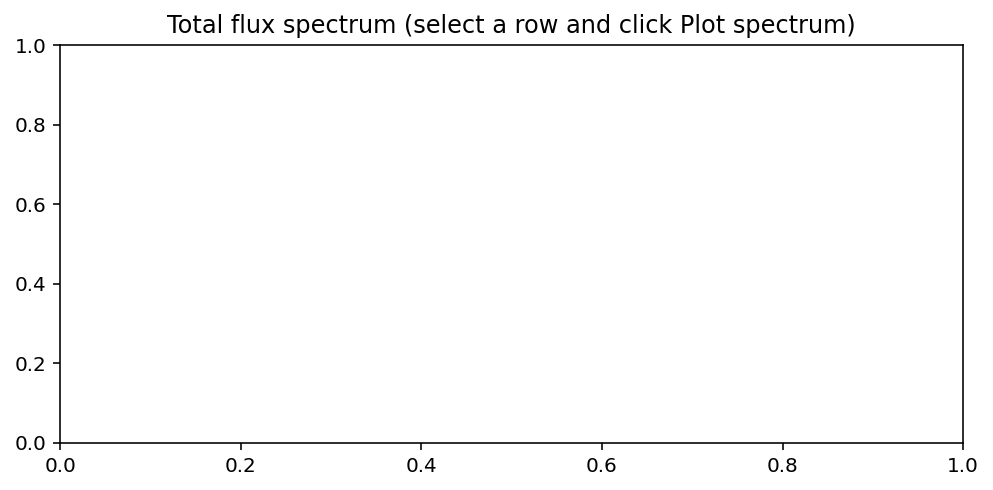
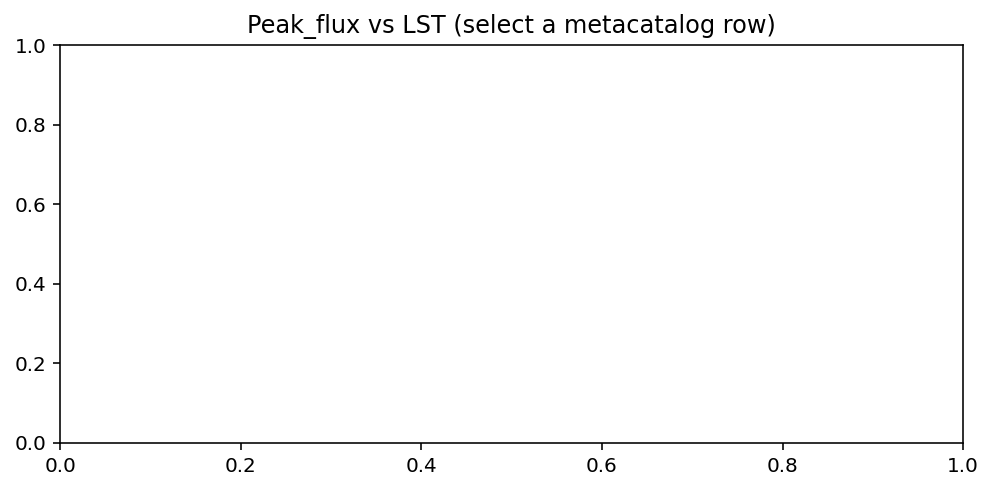
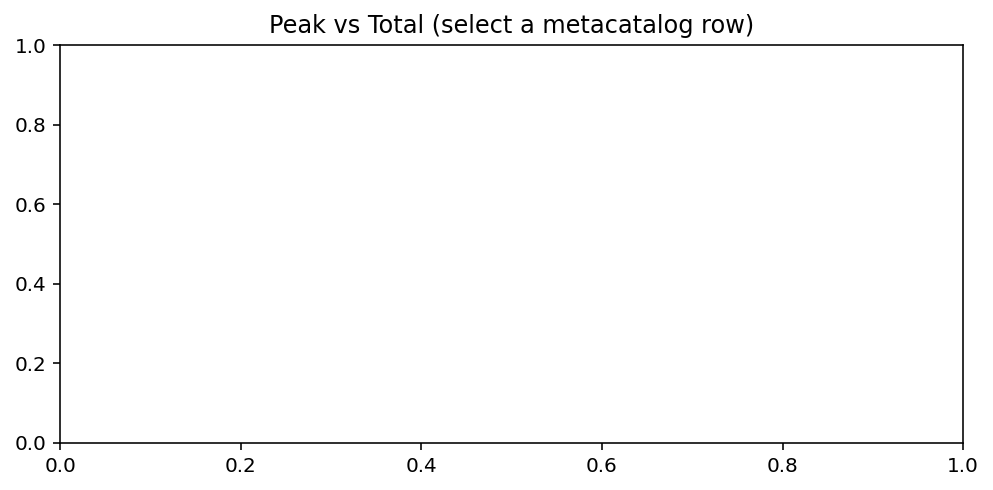
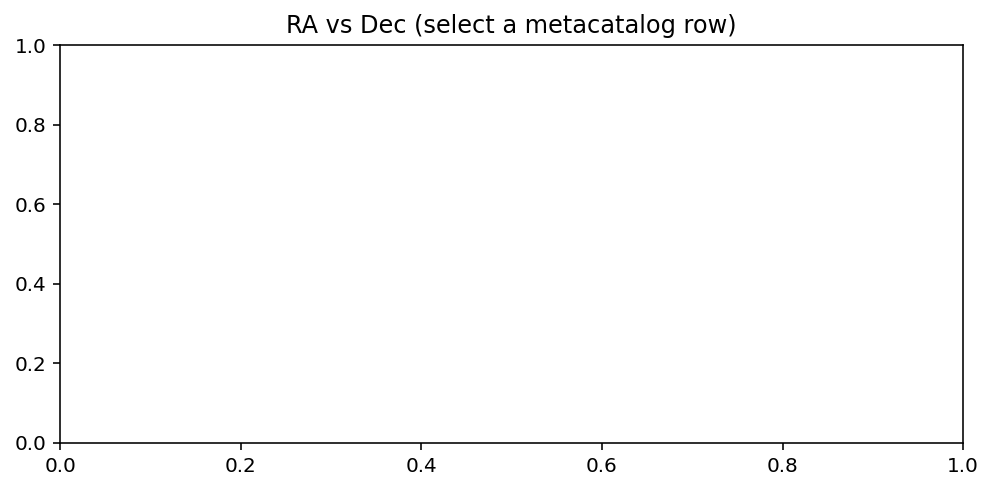
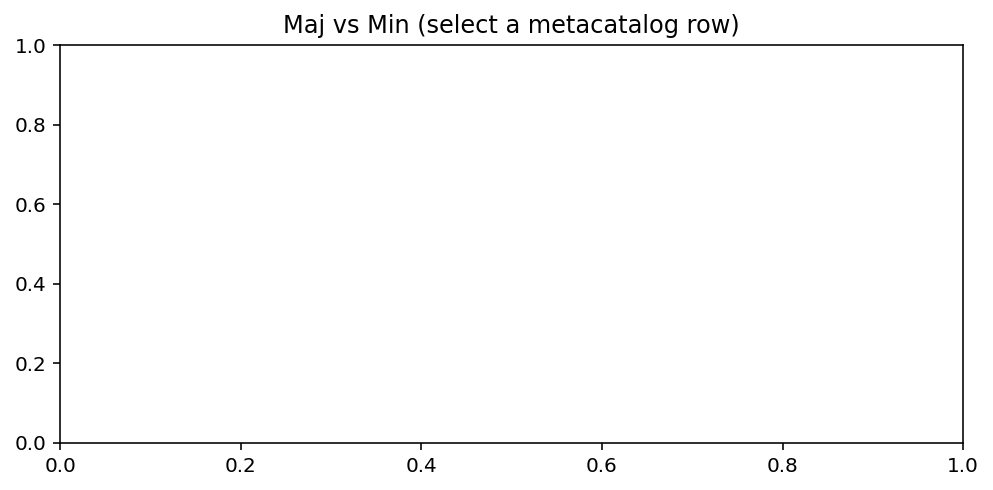

In [3]:
import threading

def order_columns(df: pd.DataFrame, *, limit: int | None = MAX_TABLE_COLUMNS) -> list[str]:
    """Return column names in preferred order; optionally truncate for display."""
    preferred = [c for c in _preferred_columns if c in df.columns]
    rest = sorted(c for c in df.columns if c not in preferred)
    cols = preferred + rest
    if limit is not None and len(cols) > limit:
        cols = cols[:limit]
    return cols


def default_display_columns(df: pd.DataFrame) -> list[str]:
    """Columns to show when loading a catalog (saved prefs, else truncated preferred set)."""
    saved = [c for c in _preferred_columns if c in df.columns]
    if saved:
        return saved
    return order_columns(df)



# Numeric header filter "compare" supports ">5", "<=8.1", "!=0", or bare "5" (≥).
# Register it on window.Tabulator before the browser tables are built.
from IPython.display import Javascript, display

_COMPARE_FILTER_INSTALL_JS = r"""
(function () {
  function install(T) {
    if (!T || T.__lwaCompareFilter) return !!T;
    T.__lwaCompareFilter = true;
    T.extendModule("filter", "filters", {
      compare: function (headerValue, rowValue, rowData, filterParams) {
        if (headerValue === null || headerValue === undefined || headerValue === '') {
          return true;
        }
        if (rowValue === null || rowValue === undefined || rowValue === '') {
          return false;
        }
        var s = String(headerValue).trim();
        var m = s.match(/^(<=|>=|<|>|!=|==|=)?\s*([+-]?(?:\d+\.?\d*|\.\d+)(?:[eE][+-]?\d+)?)\s*$/);
        if (!m) {
          return true; // incomplete while typing
        }
        var op = m[1] || '>=';
        if (op === '==') op = '=';
        var thr = parseFloat(m[2]);
        var v = Number(rowValue);
        if (Number.isNaN(v) || Number.isNaN(thr)) return false;
        switch (op) {
          case '>':  return v > thr;
          case '>=': return v >= thr;
          case '<':  return v < thr;
          case '<=': return v <= thr;
          case '!=': return v !== thr;
          case '=':  return v === thr;
          default:   return v >= thr;
        }
      }
    });
    return true;
  }
  function tryInstall() {
    if (window.Tabulator && install(window.Tabulator)) return true;
    return false;
  }
  if (!tryInstall()) {
    var n = 0;
    var id = setInterval(function () {
      if (tryInstall() || ++n > 400) clearInterval(id);
    }, 25);
  }
  if (window.requirejs) {
    try {
      requirejs(["tabulator"], function (T) { install(T || window.Tabulator); });
    } catch (e) {}
  }
})();
"""

display(Javascript(_COMPARE_FILTER_INSTALL_JS))


def header_filters_for(df: pd.DataFrame) -> dict[str, dict]:
    """Per-column Tabulator header filters (numeric comparisons, text contains)."""
    filters: dict[str, dict] = {}
    for col in df.columns:
        kind = df[col].dtype.kind
        if kind in "iuf":
            filters[col] = {
                "type": "input",
                "func": "compare",
                "placeholder": ">5 / <=8.1",
            }
        elif kind == "b":
            filters[col] = {"type": "tickCross", "tristate": True, "indeterminateValue": None}
        else:
            filters[col] = {"type": "input", "func": "like", "placeholder": "contains…"}
    return filters


_COMPARE_HEADER_RE = re.compile(
    r"^(<=|>=|<|>|!=|==|=)?\s*([+-]?(?:\d+\.?\d*|\.\d+)(?:[eE][+-]?\d+)?)\s*$"
)


def _normalize_compare_filters(filters: list) -> list:
    """Map the notebook ``compare`` header filter to Panel's remote-pagination ops."""
    out: list = []
    for filt in filters:
        if not isinstance(filt, dict) or filt.get("type") != "compare":
            out.append(filt)
            continue
        raw = filt.get("value")
        if raw is None or raw == "":
            continue
        match = _COMPARE_HEADER_RE.match(str(raw).strip())
        if not match:
            continue
        op = match.group(1) or ">="
        if op in ("==", "="):
            op = "="
        out.append({**filt, "type": op, "value": match.group(2)})
    return out


class _HeaderFilterOwner:
    """Minimal stand-in so Tabulator._get_header_filters can run without events."""

    def __init__(self, *, filters, header_filters, indexes, value):
        self.filters = filters
        self.header_filters = header_filters
        self.indexes = indexes
        self.value = value


class CatalogTabulator(pn.widgets.Tabulator):
    """Browse-table Tabulator: remote pages + numeric ``compare`` header filters."""

    def _get_header_filters(self, df: pd.DataFrame) -> list:
        holder = _HeaderFilterOwner(
            filters=_normalize_compare_filters(list(getattr(self, "filters", []) or [])),
            header_filters=self.header_filters,
            indexes=self.indexes,
            value=self.value,
        )
        return pn.widgets.Tabulator._get_header_filters(holder, df)


def nearest_sources(
    df: pd.DataFrame,
    coord: SkyCoord,
    *,
    n: int = 5,
    ra_col: str = "RA",
    dec_col: str = "DEC",
) -> pd.DataFrame:
    """Return the ``n`` catalog rows closest to ``coord`` (great-circle)."""
    if ra_col not in df.columns or dec_col not in df.columns:
        raise KeyError(f"Need {ra_col!r} and {dec_col!r} columns for sky matching")
    if df.empty:
        raise ValueError("Catalog is empty")

    catalog = SkyCoord(
        ra=np.asarray(df[ra_col], dtype=float) * u.deg,
        dec=np.asarray(df[dec_col], dtype=float) * u.deg,
        frame="icrs",
    )
    seps = coord.separation(catalog)
    order = np.argsort(seps.deg)
    n = max(1, min(int(n), len(df)))
    out = df.iloc[order[:n]].copy()
    out.insert(0, "sep_arcmin", np.round(seps.deg[order[:n]] * 60.0, 4))
    out.insert(1, "sep_deg", np.round(seps.deg[order[:n]], 6))
    # Defragment + isolate from the parent catalog (Tabulator may mutate .value in place).
    return out.reset_index(drop=True).copy()


def _mpl_configure() -> None:
    """Use a non-interactive backend once per kernel (Panel owns display)."""
    import matplotlib

    if matplotlib.get_backend().lower() != "agg":
        matplotlib.use("agg")


def _close_mpl_figure(fig) -> None:
    if fig is None:
        return
    import matplotlib.pyplot as plt

    try:
        plt.close(fig)
    except Exception:
        pass


def _mpl_new_figure(*, figsize: tuple[float, float] = (7.0, 3.5)):
    _mpl_configure()
    import matplotlib.pyplot as plt

    return plt.subplots(figsize=figsize)


def _mpl_empty_figure(title: str):
    """Create a small Agg figure with a title (for empty trace state)."""
    fig, ax = _mpl_new_figure(figsize=(7.0, 3.5))
    ax.set_title(title)
    fig.tight_layout()
    return fig


def _mpl_reset_figure(fig, title: str, *, figsize: tuple[float, float] = (7.0, 3.5)):
    """Clear an existing figure in place (avoids leaking pyplot figure handles)."""
    if fig is None:
        fig, ax = _mpl_new_figure(figsize=figsize)
    else:
        fig.clf()
        ax = fig.add_subplot(111)
    ax.set_title(title)
    fig.tight_layout()
    return fig


def _set_mpl_pane(pane, fig) -> None:
    """Assign a Matplotlib pane figure and close any replaced handle."""
    old = pane.object
    if old is fig:
        pane.param.trigger("object")
        return
    pane.object = fig
    _close_mpl_figure(old)


def _mpl_placeholder(pane, title: str) -> None:
    fig = _mpl_reset_figure(pane.object, title)
    _set_mpl_pane(pane, fig)


def _mpl_trace_figures(
    source_matches: pd.DataFrame,
    figures: tuple | None = None,
):
    """Build consistency figures (flux, RA/Dec, Maj/Min) for Panel."""
    _mpl_configure()
    import matplotlib.pyplot as plt

    from lwa_catalog.analyze import (
        plot_maj_min_scatter,
        plot_member_property_scatter,
        plot_peak_flux_vs_lst,
        plot_ra_dec_scatter,
    )

    def _axis(i: int, figsize: tuple[float, float]):
        if figures is not None and i < len(figures) and figures[i] is not None:
            fig = figures[i]
            fig.clf()
            return fig, fig.add_subplot(111)
        return plt.subplots(figsize=figsize)

    fig1, ax1 = _axis(0, (6.5, 3.4))
    plot_peak_flux_vs_lst(source_matches, ax=ax1)
    fig1.tight_layout()

    fig2, ax2 = _axis(1, (6.5, 3.4))
    plot_member_property_scatter(source_matches, ax=ax2)
    fig2.tight_layout()

    fig3, ax3 = _axis(2, (6.5, 3.4))
    plot_ra_dec_scatter(source_matches, ax=ax3)
    fig3.tight_layout()

    fig4, ax4 = _axis(3, (6.5, 3.4))
    plot_maj_min_scatter(source_matches, ax=ax4)
    fig4.tight_layout()
    return fig1, fig2, fig3, fig4


def _row_to_spectrum_fit(row: pd.Series, *, prefix: str = SPEC_COLUMN_PREFIX) -> SingleSpectrumFit | None:
    """Build a :class:`SingleSpectrumFit` from stored ``{prefix}model_*`` columns."""
    n_terms_col = f"{prefix}model_n_terms"
    if n_terms_col not in row.index or pd.isna(row.get(n_terms_col)):
        return None
    n_terms = int(row[n_terms_col])
    if n_terms < 2:
        return None
    return SingleSpectrumFit(
        n_terms=n_terms,
        bic=float(row.get(f"{prefix}model_bic", float("nan"))),
        chi2_red=float(row.get(f"{prefix}model_chi2_red", float("nan"))),
        n_flux=int(row.get(f"{prefix}model_n_flux", 0)),
        coeffs=(
            float(row.get(f"{prefix}model_a0", float("nan"))),
            float(row.get(f"{prefix}model_a1", float("nan"))),
            float(row.get(f"{prefix}model_a2", float("nan"))),
            float(row.get(f"{prefix}model_a3", float("nan"))),
        ),
        nu0_mhz=float(row.get(f"{prefix}model_nu0_mhz", SPEC_REF_FREQ_MHZ)),
    )


def _spectrum_figure_for_row(
    row: pd.Series,
    *,
    bands: tuple[str, ...] = SUBBAND_BANDS_MHZ,
    prefix: str = SPEC_COLUMN_PREFIX,
    ref_freq_mhz: float = SPEC_REF_FREQ_MHZ,
    fig=None,
):
    """Plot per-band flux measurements and optional Taylor model for one catalog row."""
    _mpl_configure()
    import matplotlib.pyplot as plt

    if fig is None:
        fig, ax = _mpl_new_figure(figsize=(7.5, 4.0))
    else:
        fig.clf()
        ax = fig.add_subplot(111)

    meta_id = row.get("meta_id")
    label = f"meta_id={int(meta_id)}" if pd.notna(meta_id) else "selected source"

    nu_hz, flux_jy, err_jy = gather_band_flux_measurements(
        row,
        bands=bands,
        flux_kind="total",
    )
    if nu_hz.size == 0:
        ax.text(
            0.5,
            0.5,
            f"{label}: no valid flux measurements",
            ha="center",
            va="center",
            transform=ax.transAxes,
        )
        ax.set_axis_off()
        fig.tight_layout()
        return fig

    nu_mhz = nu_hz / 1e6
    ax.errorbar(nu_mhz, flux_jy, yerr=err_jy, fmt="o", capsize=2, label="data")

    fit = _row_to_spectrum_fit(row, prefix=prefix)
    if fit is not None:
        nu_curve = np.geomspace(nu_mhz.min(), nu_mhz.max(), 100)
        flux_curve = evaluate_taylor_spectrum(nu_curve * 1e6, fit)
        ax.plot(nu_curve, flux_curve, "-", label=f"{fit.n_terms}-term Taylor fit")

    ax.axvline(
        ref_freq_mhz,
        color="0.5",
        ls=":",
        lw=1,
        label=f"ν₀={ref_freq_mhz:g} MHz",
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Frequency (MHz)")
    ax.set_ylabel("Total flux (Jy)")
    if fit is not None and np.isfinite(fit.chi2_red):
        ax.set_title(
            f"{label}  n_flux={fit.n_flux}  n_terms={fit.n_terms}  χ²_red={fit.chi2_red:.3g}"
        )
    elif fit is not None:
        ax.set_title(f"{label}  n_flux={fit.n_flux}  n_terms={fit.n_terms}")
    else:
        ax.set_title(f"{label}  n_flux={nu_hz.size}  (no Taylor model columns)")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize=8, loc="best")
    fig.tight_layout()
    return fig



def preferred_hips_survey(catalog_dir: Path, surveys: list[str]) -> str:
    """Pick a default HiPS survey for *catalog_dir* from *surveys*."""
    if DEFAULT_HIPS_SURVEY in surveys:
        return DEFAULT_HIPS_SURVEY
    if not surveys:
        local = discover_local_hips_surveys(catalog_dir)
        return local[0] if local else DEFAULT_HIPS_SURVEY
    name = catalog_dir.name
    for key in (f"{name}_full", f"{name}_reliable", "_full", "_reliable"):
        hit = next((s for s in surveys if key in s), None)
        if hit is not None:
            return hit
    return default_hips_survey(surveys, default_survey=DEFAULT_HIPS_SURVEY)


def browser_fetch_hips_surveys(catalog_dir: Path) -> list[str]:
    """HiPS survey list (remote list server with local catalog-dir fallback)."""
    local = discover_local_hips_surveys(catalog_dir)
    fallback = preferred_hips_survey(catalog_dir, local or []) or DEFAULT_HIPS_SURVEY
    return fetch_hips_surveys(
        HIPS_LIST_SERVER,
        catalog_dir=catalog_dir,
        default_survey=fallback,
    )


class CatalogBrowser(pn.viewable.Viewer):
    """Interactive browser for Parquet catalogs under a selectable catalog tree."""

    catalog_dir = param.Selector(
        default=str(DEFAULT_CATALOG_DIR),
        objects=[str(p) for p in CATALOG_DIRS],
        doc="Catalog tree containing Parquet files (and optional local HiPS)",
    )
    kind = param.Selector(default="all", objects=["all"], doc="Artifact kind filter")
    lst_hour = param.Selector(default="all", objects=["all"], doc="LST hour filter")
    band = param.Selector(default="all", objects=["all"], doc="Band filter")
    catalog_file = param.Selector(default="", objects=[""], doc="Selected Parquet file")
    display_columns = param.ListSelector(
        default=[],
        objects=[],
        doc="Columns shown in the browse and nearest-source tables",
    )
    coordinate = param.String(
        default="83.633 -5.391",
        doc="Query coordinate (decimal deg or sexagesimal)",
    )
    n_nearest = param.Integer(default=DEFAULT_N_NEAREST, bounds=(1, 50), doc="Neighbors to return")
    meta_id = param.Integer(default=0, bounds=(0, None), doc="Metacatalog meta_id to rematch")
    pick_on_click = param.Boolean(
        default=False,
        doc="Click the sky view to select the nearest in-FOV meta_id",
    )
    show_overlay = param.Boolean(default=True, doc="Draw catalog sources on the HiPS view")
    max_sources = param.Integer(
        default=OVERLAY_MAX_SOURCES_DEFAULT,
        bounds=OVERLAY_MAX_SOURCES_BOUNDS,
        doc="Max sources drawn inside the current FOV",
    )
    radio_qa_filter = param.String(
        default=(RADIO_QA_FILTER if isinstance(RADIO_QA_FILTER, str) else ""),
        doc="Optional pandas query string to subset the loaded catalog (Apply filter)",
    )

    def __init__(self, index: pd.DataFrame, **params):
        # Validate Selector values only after objects lists are populated.
        params = dict(params)
        params.pop("kind", None)
        params.pop("lst_hour", None)
        params.pop("band", None)
        params.pop("catalog_file", None)
        params.pop("display_columns", None)
        params.pop("catalog_dir", None)
        inventory_table = params.pop("inventory_table", None)
        super().__init__(**params)

        self._ready = False
        self._index = index.copy()
        self._df_full: pd.DataFrame | None = None
        self._df: pd.DataFrame | None = None
        self._nearest_hits: pd.DataFrame | None = None
        self._trace = None
        self._overlay_refresh: DebouncedAladinViewRefresh | None = None
        self._overlay_lock = threading.RLock()
        self._load_generation = 0
        self._suppress_file_load = False
        self._sky_loaded = False
        self._sky_center_note = ""
        self._overlay_note = ""
        self._inventory_table = inventory_table
        self._layout = CatalogLayout(Path(self.catalog_dir))
        self._status = pn.pane.Markdown("", sizing_mode="stretch_width")
        self._nearest_status = pn.pane.Markdown("", sizing_mode="stretch_width")
        self._trace_status = pn.pane.Markdown(
            "_Select a table row, then click **Load trace**._",
            sizing_mode="stretch_width",
        )

        kinds = ["all", *sorted(str(x) for x in index["kind"].dropna().unique())]
        self.param.kind.objects = kinds

        with pn.config.set(sizing_mode="stretch_width"):
            self._catalog_dir_w = pn.widgets.Select(
                name="Catalog directory",
                options={p.name: str(p) for p in CATALOG_DIRS},
                value=str(Path(self.catalog_dir).resolve()),
                sizing_mode="stretch_width",
            )
            self._catalog_dir_w.param.watch(self._on_catalog_dir_widget, "value")
            self._kind_w = pn.widgets.Select.from_param(self.param.kind, name="Kind")
            self._lst_w = pn.widgets.Select.from_param(self.param.lst_hour, name="LST hour")
            self._band_w = pn.widgets.Select.from_param(self.param.band, name="Band")
            self._file_w = pn.widgets.Select.from_param(self.param.catalog_file, name="Catalog file")
            self._file_w.param.watch(self._on_file_widget, "value")
            self._load_spinner = pn.indicators.LoadingSpinner(
                value=False,
                width=36,
                height=36,
                sizing_mode="fixed",
            )
            self._loaded_catalog = pn.pane.Markdown(
                "_No catalog loaded._",
                sizing_mode="stretch_width",
            )
            self._load_header = pn.Row(
                self._load_spinner,
                self._loaded_catalog,
                sizing_mode="stretch_width",
                align="center",
            )
            self._radio_qa_w = pn.widgets.TextInput.from_param(
                self.param.radio_qa_filter,
                name="RADIO_QA_FILTER",
                placeholder="pandas query, e.g. n_assoc_NVSS >= 1",
            )
            self._radio_qa_btn = pn.widgets.Button(
                name="Apply filter",
                button_type="primary",
                width=120,
                sizing_mode="fixed",
            )
            self._radio_qa_btn.on_click(self._on_apply_radio_qa_filter)
            self._radio_qa_clear = pn.widgets.Button(
                name="Clear",
                button_type="default",
                width=80,
                sizing_mode="fixed",
            )
            self._radio_qa_clear.on_click(self._on_clear_radio_qa_filter)
            self._cols_w = pn.widgets.MultiChoice.from_param(
                self.param.display_columns,
                name="Display columns",
                placeholder="Select columns to show…",
                solid=False,
                option_limit=80,
                search_option_limit=80,
            )
            self._save_cols_btn = pn.widgets.Button(
                name="Save as default",
                button_type="default",
                width=140,
                sizing_mode="fixed",
            )
            self._save_cols_btn.on_click(self._on_save_columns)
            self._coord_w = pn.widgets.TextInput.from_param(
                self.param.coordinate, name="Coordinate", placeholder="RA Dec"
            )
            self._n_w = pn.widgets.IntInput.from_param(self.param.n_nearest, name="N nearest")
            self._sky_btn = pn.widgets.Button(
                name="Load sky view",
                button_type="primary",
                width=150,
                sizing_mode="fixed",
            )
            self._sky_btn.on_click(self._on_load_sky)
            self._spectrum_btn = pn.widgets.Button(
                name="Plot spectrum",
                button_type="primary",
                width=150,
                sizing_mode="fixed",
            )
            self._spectrum_btn.on_click(self._on_plot_spectrum)
            self._find_btn = pn.widgets.Button(
                name="Load nearest",
                button_type="primary",
                width=150,
                sizing_mode="fixed",
            )
            self._find_btn.on_click(self._on_find_nearest)

            self._table = CatalogTabulator(
                pd.DataFrame(),
                pagination="remote",
                page_size=TABLE_PAGE_SIZE,
                height=TABLE_HEIGHT,
                sizing_mode="stretch_width",
                layout="fit_columns",
                header_filters={},
                show_index=False,
                disabled=True,
                sortable=True,
                selectable=1,
                configuration={"filterMode": "remote"},
            )
            self._table.param.watch(self._on_table_select, "selection")

            self._nearest_table = pn.widgets.Tabulator(
                pd.DataFrame(),
                pagination=None,
                height=220,
                sizing_mode="stretch_width",
                layout="fit_data_table",
                show_index=False,
                disabled=True,
                sortable=True,
            )

            self._lst_trace_table = pn.widgets.Tabulator(
                pd.DataFrame(),
                pagination=None,
                height=180,
                sizing_mode="stretch_width",
                layout="fit_data_table",
                show_index=False,
                disabled=True,
                sortable=True,
            )
            self._src_trace_table = pn.widgets.Tabulator(
                pd.DataFrame(),
                pagination="local",
                page_size=25,
                height=260,
                sizing_mode="stretch_width",
                layout="fit_data_table",
                show_index=False,
                disabled=True,
                sortable=True,
            )
            self._meta_id_w = pn.widgets.IntInput.from_param(
                self.param.meta_id, name="meta_id", width=140
            )
            self._trace_btn = pn.widgets.Button(
                name="Load trace",
                button_type="primary",
                width=150,
                sizing_mode="fixed",
            )
            self._trace_btn.on_click(self._on_load_trace)

            hips_surveys = browser_fetch_hips_surveys(Path(self.catalog_dir))
            hips_default = preferred_hips_survey(Path(self.catalog_dir), hips_surveys)
            init_coord = parse_coordinate(self.coordinate)

            from ipyaladin import Aladin

            self._pick_w = pn.widgets.Checkbox.from_param(
                self.param.pick_on_click,
                name="Pick nearest on sky click",
            )
            self._overlay_w = pn.widgets.Checkbox.from_param(
                self.param.show_overlay,
                name="Show catalog overlay",
            )
            self._hips_survey_w = pn.widgets.Select(
                name="HiPS survey",
                options=hips_surveys,
                value=hips_default,
                sizing_mode="stretch_width",
            )
            self._hips_status = pn.pane.Markdown(
                "_Sky overlay loads for the first table row; **Load sky view** recenters on the selection._",
                sizing_mode="stretch_width",
            )
            self._save_sky_btn = pn.widgets.Button(
                name="Save sky PNG",
                button_type="default",
                width=140,
                sizing_mode="fixed",
            )
            self._save_sky_btn.on_click(self._on_save_sky_png)
            self._hips_current_survey = hips_survey_url(hips_default, base=HIPS_SERVER)
            self._aladin = Aladin(
                survey=self._hips_current_survey,
                target=init_coord,
                fov=SKY_FOV_DEG,
                height=HIPS_VIEW_HEIGHT,
            )
            self._hips_view = pn.pane.IPyWidget(
                self._aladin,
                height=HIPS_VIEW_HEIGHT + 20,
                sizing_mode="stretch_width",
            )
            self._aladin.set_listener("click", self._on_sky_click)
            self._overlay_refresh = DebouncedAladinViewRefresh(
                self._aladin,
                self._refresh_overlay_from_aladin,
                enabled=lambda: self._ready and self.show_overlay and self._sky_loaded,
            )
            self._hips_survey_w.param.watch(self._on_hips_survey_change, "value")
            self._overlay_w.param.watch(self._on_overlay_change, "value")

            empty1 = _mpl_empty_figure("Peak_flux vs LST (select a metacatalog row)")
            empty2 = _mpl_empty_figure("Peak vs Total (select a metacatalog row)")
            empty3 = _mpl_empty_figure("RA vs Dec (select a metacatalog row)")
            empty4 = _mpl_empty_figure("Maj vs Min (select a metacatalog row)")
            self._flux_plot = pn.pane.Matplotlib(empty1, tight=True, height=320)
            self._scatter_plot = pn.pane.Matplotlib(empty2, tight=True, height=320)
            self._radec_plot = pn.pane.Matplotlib(empty3, tight=True, height=320)
            self._majmin_plot = pn.pane.Matplotlib(empty4, tight=True, height=320)
            self._spectrum_status = pn.pane.Markdown(
                "_Select a table row, then click **Plot spectrum**._",
                sizing_mode="stretch_width",
            )
            empty_spec = _mpl_empty_figure(
                "Total flux spectrum (select a row and click Plot spectrum)"
            )
            self._spectrum_plot = pn.pane.Matplotlib(empty_spec, tight=True, height=360)

            self._panel = pn.Column(
                self._catalog_dir_w,
                pn.Row(self._kind_w, self._lst_w, self._band_w),
                self._file_w,
                self._load_header,
                pn.Row(self._radio_qa_w, self._radio_qa_btn, self._radio_qa_clear, align="end"),
                pn.Row(self._cols_w, self._save_cols_btn),
                self._status,
                self._table,
                pn.pane.Markdown("### Sky context (HiPS + catalog overlay)", disable_anchors=True),
                pn.Row(self._hips_survey_w, self._sky_btn, align="end"),
                self._pick_w,
                pn.Row(self._overlay_w, self._save_sky_btn, align="center"),
                self._hips_status,
                self._hips_view,
                pn.pane.Markdown(
                    "### Spectral flux (subband SED)\n"
                    "Select a browse-table row (the same source as **Load sky view**), "
                    "then click **Plot spectrum**. Per-band `Total_flux_{band}` measurements "
                    "are shown with the stored Taylor model when `spec_model_*` columns are present "
                    "(e.g. `metacatalog_spectral.parquet`).",
                    disable_anchors=True,
                ),
                pn.Row(self._spectrum_btn),
                self._spectrum_status,
                self._spectrum_plot,
                pn.pane.Markdown(
                    "### Source trace (rematch)\n"
                    "Select a table row, then click **Load trace**. Rematch uses beam "
                    "association and keeps the highest-elevation seed; durable key "
                    "`(band, lst_hour, Source_id)`. Updates the tables and plots below; "
                    "does not change the sky overlay.",
                    disable_anchors=True,
                ),
                pn.Row(self._meta_id_w, self._trace_btn),
                self._trace_status,
                pn.pane.Markdown("#### LST-merged matches", disable_anchors=True),
                self._lst_trace_table,
                pn.pane.Markdown("#### Per-hour source matches", disable_anchors=True),
                self._src_trace_table,
                pn.Row(self._flux_plot, self._scatter_plot),
                pn.Row(self._radec_plot, self._majmin_plot),
                pn.pane.Markdown("### Nearest-source query", disable_anchors=True),
                pn.Row(self._coord_w, self._n_w, self._find_btn),
                self._nearest_status,
                self._nearest_table,
            )

        self._ready = True
        self._suppress_file_load = True
        self.kind = "all"
        self._sync_filters()
        self._load_selected(show_loading=False)
        self._suppress_file_load = False

    def __panel__(self):
        return self._panel

    def _on_catalog_dir_widget(self, event) -> None:
        if not getattr(self, "_ready", False):
            return
        if event.new and str(event.new) != str(self.catalog_dir):
            self.catalog_dir = str(event.new)

    @param.depends("catalog_dir", watch=True, on_init=False)
    def _on_catalog_dir_change(self) -> None:
        if not getattr(self, "_ready", False):
            return
        catalog_dir = Path(self.catalog_dir)
        self._layout = CatalogLayout(catalog_dir)
        self._index = inventory_catalogs(catalog_dir)
        if self._inventory_table is not None:
            self._inventory_table.value = self._index.drop(columns=["path"])

        kinds = ["all", *sorted(str(x) for x in self._index["kind"].dropna().unique())]
        self.param.kind.objects = kinds
        if self.kind not in kinds:
            self.kind = "all"

        widget_value = str(catalog_dir.resolve())
        if self._catalog_dir_w.value != widget_value:
            self._catalog_dir_w.value = widget_value

        surveys = browser_fetch_hips_surveys(catalog_dir)
        default = preferred_hips_survey(catalog_dir, surveys)
        self._hips_survey_w.options = surveys
        if default and self._hips_survey_w.value not in surveys:
            self._hips_survey_w.value = default
        if default:
            self._set_hips_survey(default)

        self._sky_loaded = False
        self._sync_filters()
        self._load_selected()

    def select_file(self, filename: str) -> None:
        """Select a catalog by filename (updates kind / LST / band filters)."""
        rows = self._index.loc[self._index["file"] == filename]
        if rows.empty:
            raise KeyError(f"Unknown catalog file: {filename}")
        row = rows.iloc[0]
        kind = str(row["kind"])
        if kind not in self.param.kind.objects:
            self.param.kind.objects = ["all", *sorted(set(self.param.kind.objects) | {kind})]
        # Batch param updates so throttled watchers do not reset catalog_file mid-select.
        with param.parameterized.batch_call_watchers(self):
            self.kind = kind
            self._sync_filters()
            if filename not in self.param.catalog_file.objects:
                self.param.catalog_file.objects = [*self.param.catalog_file.objects, filename]
            self.catalog_file = filename

    def _filtered_index(self) -> pd.DataFrame:
        df = self._index
        if self.kind != "all":
            df = df[df["kind"] == self.kind]
        if self.lst_hour != "all":
            df = df[df["lst_hour"] == self.lst_hour]
        if self.band != "all":
            df = df[df["band"] == self.band]
        return df

    def _is_metacatalog(self) -> bool:
        if self._df is None or self._df.empty:
            return False
        if "meta_id" not in self._df.columns:
            return False
        return is_metacatalog_parquet(str(self.catalog_file))

    @param.depends("kind", watch=True, on_init=False)
    def _on_kind_change(self) -> None:
        if not getattr(self, "_ready", False):
            return
        self._sync_filters()

    @param.depends("lst_hour", "band", watch=True, on_init=False)
    def _on_subfilter_change(self) -> None:
        if not getattr(self, "_ready", False):
            return
        self._sync_file_options(reset_if_missing=True)

    def _on_file_widget(self, event) -> None:
        if not getattr(self, "_ready", False) or getattr(self, "_suppress_file_load", False):
            return
        filename = str(event.new or "")
        if filename and filename != str(self.catalog_file):
            self.catalog_file = filename
        self._load_selected()

    @param.depends("display_columns", watch=True, on_init=False)
    def _on_columns_change(self) -> None:
        if not getattr(self, "_ready", False):
            return
        self._apply_display_columns()

    def _sync_filters(self) -> None:
        base = self._index if self.kind == "all" else self._index[self._index["kind"] == self.kind]
        lst_opts = ["all", *sorted(str(x) for x in base["lst_hour"].dropna().unique())]
        band_opts = ["all", *sorted(str(x) for x in base["band"].dropna().unique())]
        self.param.lst_hour.objects = lst_opts
        self.param.band.objects = band_opts
        if self.lst_hour not in lst_opts:
            self.lst_hour = "all"
        if self.band not in band_opts:
            self.band = "all"
        self._sync_file_options(reset_if_missing=True)

    def _sync_file_options(self, *, reset_if_missing: bool) -> None:
        files = self._filtered_index()["file"].tolist() or [""]
        self.param.catalog_file.objects = files
        if files == [""]:
            self.catalog_file = ""
            return
        if reset_if_missing and self.catalog_file not in files:
            preferred = [
                "metacatalog_quality.parquet",
                "metacatalog_spectral.parquet",
                "metacatalog.parquet",
            ]
            preferred += [f for f in files if f.endswith("_Full.parquet")]
            self.catalog_file = next((f for f in preferred if f in files), files[0])

    def _set_table_value(self, table: pn.widgets.Tabulator, df: pd.DataFrame) -> None:
        """Assign a defensive copy so Tabulator cannot mutate catalog/hit frames."""
        safe = df.reset_index(drop=True).copy()
        new_cols = list(safe.columns)
        old = table.value
        old_cols = list(old.columns) if old is not None else None
        cols_changed = old_cols is not None and old_cols != new_cols
        if cols_changed:
            # Stale JS header filters/sorters on removed fields hide every row.
            table.filters = []
            table.sorters = []
            if table.pagination:
                table.page = 1
        if table is self._table and (cols_changed or old_cols is None):
            table.header_filters = header_filters_for(safe) if new_cols else {}
        # One CDS update with the full frame. A 0-row "clear first" assignment
        # (to force column rebuilds) is applied after the data on the frontend
        # and leaves the browse table blank when display columns change.
        table.value = safe

    def _reveal_table_row(self, row_idx: int) -> None:
        """Select a browse-table iloc, paging to it under remote pagination."""
        table = self._table
        view = table.value
        if view is None or row_idx < 0 or row_idx >= len(view):
            return
        page_size = int(table.page_size or TABLE_PAGE_SIZE)
        processed = getattr(table, "_processed", None)
        if table.pagination == "remote" and processed is not None and not processed.empty:
            try:
                label = view.index[row_idx]
                pos = processed.index.get_loc(label)
                if not isinstance(pos, (int, np.integer)):
                    pos = int(np.asarray(pos).flat[0])
                table.page = int(pos) // page_size + 1
            except (KeyError, IndexError, TypeError):
                table.page = row_idx // page_size + 1
        table.selection = [int(row_idx)]

    def _selected_columns(self) -> list[str]:
        """Ordered intersection of the user's column picks with the loaded table."""
        if self._df is None:
            return []
        available = set(self._df.columns)
        chosen = [c for c in self.display_columns if c in available]
        if not chosen:
            return default_display_columns(self._df)
        # Keep preferred ordering among the selected set
        return [c for c in order_columns(self._df, limit=None) if c in set(chosen)]

    def _apply_nearest_columns(self) -> None:
        if self._nearest_hits is None or self._nearest_hits.empty:
            self._set_table_value(self._nearest_table, pd.DataFrame())
            return
        cols = ["sep_arcmin", "sep_deg", *self._selected_columns()]
        cols = [c for c in cols if c in self._nearest_hits.columns]
        self._set_table_value(self._nearest_table, self._nearest_hits.loc[:, cols])

    def _apply_display_columns(self) -> None:
        if self._df is None:
            self._loaded_catalog.object = "_No catalog loaded._"
            self._set_table_value(self._table, pd.DataFrame())
            self._apply_nearest_columns()
            return
        cols = self._selected_columns()
        self._set_table_value(self._table, self._df.loc[:, cols])
        skipped = len(self._df.columns) - len(cols)
        extra = f" (showing {len(cols)}/{len(self._df.columns)} columns)" if skipped else ""
        hint = ""
        if self._is_metacatalog():
            hint = " First row is selected with sky overlay; **Load sky view** recenters."
        self._update_loaded_catalog_header()
        self._status.object = (
            f"Showing **{len(cols):,}** of **{len(self._df.columns):,}** columns{extra}. "
            "Click headers to sort; numeric filters: `>5`, `<=8.1`, or bare `5` (≥)."
            f"{hint}"
        )
        self._apply_nearest_columns()

    def close_mpl_figures(self) -> None:
        """Close trace Matplotlib figures (call before discarding this browser)."""
        for pane in (
            self._flux_plot,
            self._scatter_plot,
            self._radec_plot,
            self._majmin_plot,
            self._spectrum_plot,
        ):
            _close_mpl_figure(pane.object)
            pane.object = None

    def _clear_trace(self, message: str) -> None:
        self._trace = None
        clear_trace_overlays(self._aladin)
        self._trace_status.object = message
        self._set_table_value(self._lst_trace_table, pd.DataFrame())
        self._set_table_value(self._src_trace_table, pd.DataFrame())
        for pane, title in (
            (self._flux_plot, "Peak_flux vs LST (select a metacatalog row)"),
            (self._scatter_plot, "Peak vs Total (select a metacatalog row)"),
            (self._radec_plot, "RA vs Dec (select a metacatalog row)"),
            (self._majmin_plot, "Maj vs Min (select a metacatalog row)"),
        ):
            _mpl_placeholder(pane, title)


    def _catalog_header_markdown(
        self,
        filename: str,
        *,
        state: str = "loaded",
        rows: int | None = None,
        cols: int | None = None,
        rows_full: int | None = None,
        error: str | None = None,
        filter_expr: str | None = None,
    ) -> str:
        path = Path(self.catalog_dir) / filename
        if state == "loading":
            return (
                "### Loading catalog…\n\n"
                f"**`{filename}`**\n\n"
                f"`{path}`"
            )
        if state == "error":
            return (
                "### Catalog load failed\n\n"
                f"**`{filename}`**\n\n"
                f"`{path}`\n\n"
                f"_{error}_"
            )
        stats = ""
        if rows is not None and cols is not None:
            if rows_full is not None and rows_full != rows:
                stats = (
                    f" — **{rows:,}** / **{rows_full:,}** rows × **{cols:,}** columns"
                )
            else:
                stats = f" — **{rows:,}** rows × **{cols:,}** columns"
        filt = ""
        if filter_expr:
            filt = f"\n\n`RADIO_QA_FILTER = {filter_expr!r}`"
        return (
            f"### Loaded catalog{stats}\n\n"
            f"**`{filename}`**\n\n"
            f"`{path}`{filt}"
        )

    def _update_loaded_catalog_header(self) -> None:
        if not self.catalog_file or self._df is None:
            self._loaded_catalog.object = "_No catalog loaded._"
            return
        filt = (self.radio_qa_filter or "").strip()
        rows_full = len(self._df_full) if self._df_full is not None else None
        self._loaded_catalog.object = self._catalog_header_markdown(
            str(self.catalog_file),
            rows=len(self._df),
            cols=len(self._df.columns),
            rows_full=rows_full,
            filter_expr=filt or None,
        )

    def _set_catalog_loading(self, loading: bool, filename: str | None = None) -> None:
        self._load_spinner.value = loading
        self._table.loading = loading
        for widget in (
            self._file_w,
            self._kind_w,
            self._lst_w,
            self._band_w,
            self._radio_qa_w,
            self._radio_qa_btn,
            self._radio_qa_clear,
        ):
            widget.disabled = loading
        if loading and filename:
            self._loaded_catalog.object = self._catalog_header_markdown(
                filename,
                state="loading",
            )

    def _handle_catalog_load_error(self, exc: Exception) -> None:
        filename = str(self.catalog_file) if self.catalog_file else ""
        self._df_full = None
        self._df = None
        self._nearest_hits = None
        self._set_table_value(self._table, pd.DataFrame())
        self._set_table_value(self._nearest_table, pd.DataFrame())
        if filename:
            self._loaded_catalog.object = self._catalog_header_markdown(
                filename,
                state="error",
                error=str(exc),
            )
        else:
            self._loaded_catalog.object = "_No catalog loaded._"
        self._status.object = f"**Load failed:** `{exc}`"
        self._nearest_status.object = ""

    def _apply_empty_catalog(self) -> None:
        self._table.selection = []
        self._df_full = None
        self._df = None
        self._nearest_hits = None
        self.param.display_columns.objects = []
        self.display_columns = []
        self._set_table_value(self._table, pd.DataFrame())
        self._set_table_value(self._nearest_table, pd.DataFrame())
        self._loaded_catalog.object = "_No catalog matches the current filters._"
        self._status.object = ""
        self._nearest_status.object = ""
        self._reset_sky_context()
        self._clear_trace("_Select a table row, then click **Load trace**._")

    def _resolved_radio_qa_filter(self):
        """UI query string, else non-string config ``RADIO_QA_FILTER``."""
        text = (self.radio_qa_filter or "").strip()
        if text:
            return text
        if RADIO_QA_FILTER is not None and not isinstance(RADIO_QA_FILTER, str):
            return RADIO_QA_FILTER
        return None

    def _on_apply_radio_qa_filter(self, _event=None) -> None:
        global RADIO_QA_FILTER
        text = (self.radio_qa_filter or "").strip()
        RADIO_QA_FILTER = text or None
        self._publish_filtered_catalog()

    def _on_clear_radio_qa_filter(self, _event=None) -> None:
        global RADIO_QA_FILTER
        self.radio_qa_filter = ""
        RADIO_QA_FILTER = None
        self._publish_filtered_catalog()

    def _publish_filtered_catalog(self) -> None:
        """Apply ``RADIO_QA_FILTER`` to ``_df_full`` and refresh the browse table."""
        if self._df_full is None:
            self._status.object = "_Load a catalog before applying RADIO_QA_FILTER._"
            return
        try:
            df = apply_radio_qa_filter(self._df_full, self._resolved_radio_qa_filter())
        except Exception as exc:
            if self._df is None:
                self._apply_filtered_catalog(self._df_full)
            self._status.object = f"**RADIO_QA_FILTER failed:** `{exc}`"
            return
        self._apply_filtered_catalog(df)
        if df.empty and self._resolved_radio_qa_filter() is not None:
            self._status.object = (
                "_Filtered catalog is empty; relax **RADIO_QA_FILTER**._"
            )

    def _apply_filtered_catalog(self, df: pd.DataFrame) -> None:
        """Publish a filtered view of ``_df_full`` into the browse UI."""
        self._table.selection = []
        self._df = df
        self._nearest_hits = None
        self._trace = None
        all_cols = order_columns(df, limit=None)
        kept = [c for c in self.display_columns if c in all_cols]
        self.param.display_columns.objects = all_cols
        self.display_columns = kept if kept else default_display_columns(df)
        self._apply_display_columns()
        self._nearest_status.object = ""
        filt = self._resolved_radio_qa_filter()
        if filt is None:
            self._status.object = ""
        elif isinstance(filt, str):
            self._status.object = (
                f"RADIO_QA_FILTER → **{len(df):,}** / **{len(self._df_full):,}** rows "
                f"(`{filt}`)."
            )
        else:
            self._status.object = (
                f"RADIO_QA_FILTER → **{len(df):,}** / **{len(self._df_full):,}** rows."
            )
        self._reset_sky_context()
        if not df.empty:
            self._reveal_table_row(0)
            row = self._selected_table_row()
            if row is None:
                row = df.iloc[0]
            if "meta_id" in row.index and pd.notna(row.get("meta_id")):
                self.meta_id = int(row["meta_id"])
            self._sky_loaded = True
            self._apply_row_coordinate(row)
        if self._is_metacatalog():
            self._clear_trace("_Select a table row, then click **Load trace**._")
        else:
            self._clear_trace(
                "_Source trace needs a metacatalog-style table with `meta_id` "
                "(e.g. `metacatalog.parquet`, `metacatalog_resid_mask247.parquet`)._"
            )

    def _apply_loaded_catalog(self, df: pd.DataFrame) -> None:
        """Store quality-cleared catalog and publish with the current RADIO_QA_FILTER."""
        self._df_full = df
        self._publish_filtered_catalog()

    def _load_selected(self, *, show_loading: bool = True) -> None:
        filename = str(self.catalog_file) if self.catalog_file else ""
        if not show_loading:
            if not filename:
                self._apply_empty_catalog()
            else:
                path = Path(self.catalog_dir) / filename
                self._apply_loaded_catalog(apply_catalog_row_filters(read_table(path, as_pandas=True)))
            return

        self._load_generation += 1
        generation = self._load_generation
        self._set_catalog_loading(True, filename or None)

        def _worker() -> None:
            error: Exception | None = None
            df: pd.DataFrame | None = None
            empty = not filename
            try:
                if not empty:
                    path = Path(self.catalog_dir) / filename
                    df = apply_catalog_row_filters(read_table(path, as_pandas=True))
            except Exception as exc:
                error = exc

            def _finalize() -> None:
                if generation != self._load_generation:
                    return
                try:
                    if error is not None:
                        self._handle_catalog_load_error(error)
                    elif empty:
                        self._apply_empty_catalog()
                    else:
                        assert df is not None
                        self._apply_loaded_catalog(df)
                finally:
                    self._set_catalog_loading(False)

            pn.state.execute(_finalize)

        threading.Thread(target=_worker, daemon=True, name="catalog-load").start()


    def _require_selected_row(self, *, status: pn.pane.Markdown, label: str) -> pd.Series | None:
        row = self._selected_table_row()
        if row is None:
            status.object = f"_Select a table row, then click **{label}**._"
            return None
        return row

    def _reset_sky_context(self) -> None:
        self._sky_loaded = False
        if self._overlay_refresh is not None:
            self._overlay_refresh.cancel_pending()
        try:
            clear_trace_overlays(self._aladin)
            clear_catalog_overlays(self._aladin)
        except Exception:
            pass
        self._sky_center_note = ""
        self._overlay_note = ""
        self._hips_status.object = (
            "_Sky overlay loads for the first table row; **Load sky view** recenters on the selection._"
        )
        self._reset_spectrum_context()

    def _reset_spectrum_context(self) -> None:
        self._spectrum_status.object = "_Select a table row, then click **Plot spectrum**._"
        _mpl_placeholder(
            self._spectrum_plot,
            "Total flux spectrum (select a row and click Plot spectrum)",
        )

    def _row_sky_coord(self, row: pd.Series) -> SkyCoord | None:
        if "RA" not in row.index or "DEC" not in row.index:
            return None
        if pd.isna(row["RA"]) or pd.isna(row["DEC"]):
            return None
        return SkyCoord(
            ra=float(row["RA"]) * u.deg,
            dec=float(row["DEC"]) * u.deg,
            frame="icrs",
        )

    def _apply_row_coordinate(self, row: pd.Series) -> None:
        coord = self._row_sky_coord(row)
        if coord is None:
            return
        self.coordinate = format_coordinate_deg(coord.ra.deg, coord.dec.deg)
        self._update_sky_view(row)

    def _selected_table_row(self) -> pd.Series | None:
        """Row selected in the browse table (uses the displayed Tabulator frame)."""
        if not self._table.selection or self._df is None:
            return None
        view = self._table.value
        if view is None or view.empty:
            return None
        idx = int(self._table.selection[0])
        if idx < 0 or idx >= len(view):
            return None
        return view.iloc[idx]

    def _catalog_row_for_selection(self) -> pd.Series | None:
        """Full catalog row for the browse-table selection (not display-truncated)."""
        if self._df is None or self._df.empty:
            return None
        view_row = self._selected_table_row()
        if view_row is None:
            return None
        if "meta_id" in view_row.index and pd.notna(view_row.get("meta_id")):
            if "meta_id" in self._df.columns:
                matches = self._df.loc[self._df["meta_id"] == view_row["meta_id"]]
                if not matches.empty:
                    return matches.iloc[0]
        sel_idx = self._overlay_selection_idx()
        if sel_idx is not None and 0 <= sel_idx < len(self._df):
            return self._df.iloc[sel_idx]
        return view_row

    def _on_plot_spectrum(self, _event=None) -> None:
        if self._df is None or self._df.empty:
            self._spectrum_status.object = "**Load a catalog first.**"
            return
        row = self._catalog_row_for_selection()
        if row is None:
            self._spectrum_status.object = "_Select a table row, then click **Plot spectrum**._"
            return

        nu_hz, _, _ = gather_band_flux_measurements(
            row,
            bands=SUBBAND_BANDS_MHZ,
            flux_kind="total",
        )
        if nu_hz.size == 0:
            self._spectrum_status.object = (
                "**No per-band Total_flux_{band} measurements** for the selected row "
                "(try a subband metacatalog or `metacatalog_spectral.parquet`)."
            )
            _mpl_placeholder(
                self._spectrum_plot,
                "No flux measurements for selection",
            )
            return

        fig = _spectrum_figure_for_row(row, fig=self._spectrum_plot.object)
        _set_mpl_pane(self._spectrum_plot, fig)
        if "meta_id" in row.index and pd.notna(row.get("meta_id")):
            label = f"meta_id={int(row['meta_id'])}"
        else:
            label = "selected source"
        model_note = ""
        if _row_to_spectrum_fit(row) is None:
            model_note = " (flux only; no `spec_model_*` fit on this row)"
        self._spectrum_status.object = (
            f"**{label}** — plotted {nu_hz.size} flux channel(s){model_note}."
        )

    def _overlay_selection_idx(self) -> int | None:
        row = self._selected_table_row()
        if row is None or self._df is None:
            return None
        if "meta_id" in row.index and pd.notna(row.get("meta_id")) and "meta_id" in self._df.columns:
            match = self._df.index[self._df["meta_id"] == row["meta_id"]]
            if len(match):
                loc = self._df.index.get_loc(match[0])
                return int(loc) if isinstance(loc, int) else int(loc[0])
        idx = int(self._table.selection[0])
        if 0 <= idx < len(self._df):
            return idx
        return None

    def _render_sky_status(self) -> None:
        parts = [p for p in (self._sky_center_note, self._overlay_note) if p]
        self._hips_status.object = " ".join(parts) if parts else ""

    def _set_sky_center_note(self, text: str) -> None:
        self._sky_center_note = text
        self._render_sky_status()

    def _set_overlay_note(self, text: str) -> None:
        self._overlay_note = text
        self._render_sky_status()

    def _refresh_overlay(
        self,
        coord: SkyCoord | None = None,
        *,
        fov_deg: float | None = None,
    ) -> None:
        with self._overlay_lock:
            if self._overlay_refresh is not None:
                self._overlay_refresh.cancel_pending()
            if coord is None or fov_deg is None:
                view_coord, view_fov = aladin_view_center_fov(self._aladin)
                coord = coord or view_coord
                fov_deg = fov_deg if fov_deg is not None else view_fov

            catalog_name = catalog_name_from_file(self.catalog_file or "catalog")
            fov = float(fov_deg)

            if not self.show_overlay:
                overlay_catalog_by_band(
                    self._aladin,
                    pd.DataFrame(),
                    catalog_name,
                    coord,
                    fov,
                    replace=True,
                )
                clear_trace_overlays(self._aladin)
                self._set_overlay_note("Overlay off.")
                return

            if self._df is None or self._df.empty:
                overlay_catalog_by_band(
                    self._aladin,
                    pd.DataFrame(),
                    catalog_name,
                    coord,
                    fov,
                    replace=True,
                )
                clear_trace_overlays(self._aladin)
                self._set_overlay_note("Load a catalog to draw overlays.")
                return

            result = overlay_catalog_by_band(
                self._aladin,
                self._df,
                catalog_name,
                coord,
                fov,
                max_rows=int(self.max_sources),
                selection_idx=self._overlay_selection_idx(),
            )
            cap_note = f" (capped at {self.max_sources})" if result.truncated else ""
            clear_trace_overlays(self._aladin)

            self._set_overlay_note(
                f"Overlay: {result.drawn} drawn, {result.in_fov} in FOV{cap_note} "
                f"— `{self.catalog_file}`."
            )

    def _refresh_overlay_from_aladin(self) -> None:
        if not self._ready:
            return
        try:
            with self._overlay_lock:
                self._refresh_overlay()
        except Exception as exc:
            self._set_overlay_note(f"**Overlay refresh failed:** `{exc}`")

    def _on_overlay_change(self, _event=None) -> None:
        if not self._ready:
            return
        try:
            self._refresh_overlay()
        except Exception as exc:
            self._set_overlay_note(f"**Overlay refresh failed:** `{exc}`")

    def _on_save_sky_png(self, _event=None) -> None:
        """Save the current HiPS view via ipyaladin (quick QA screenshot)."""
        screenshot_dir = Path(self.catalog_dir) / "sky_screenshots"
        screenshot_dir.mkdir(parents=True, exist_ok=True)
        stamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")
        path = screenshot_dir / f"query_sky_{stamp}.png"
        try:
            self._aladin.save_view_as_image(path, image_format="png", with_logo=True)
        except Exception as exc:
            self._hips_status.object = f"**Save sky PNG failed:** `{exc}`"
            return
        self._hips_status.object = f"Saved sky view → `{path}`"

    def _set_hips_survey(self, survey_name: str) -> None:
        """Switch HiPS layer only when the survey selection changes."""
        url = hips_survey_url(survey_name, base=HIPS_SERVER)
        if url == self._hips_current_survey:
            return
        self._aladin.survey = url
        self._hips_current_survey = url

    def _update_sky_view(self, row: pd.Series, *, refresh_widget: bool = False) -> None:
        coord = self._row_sky_coord(row)
        if coord is None:
            return
        self._set_hips_survey(str(self._hips_survey_w.value))
        self._aladin.target = coord
        self._aladin.fov = float(SKY_FOV_DEG)
        if refresh_widget:
            # Panel Matplotlib/trace updates can blank ipyaladin's WebGL canvas.
            self._hips_view.object = self._aladin
        label = ""
        if "meta_id" in row.index and pd.notna(row.get("meta_id")):
            label = f"**meta_id={int(row['meta_id'])}** — "
        self._set_sky_center_note(
            f"{label}RA={coord.ra.deg:.6f}, Dec={coord.dec.deg:.6f} "
            f"(FOV={SKY_FOV_DEG:.2f}°)."
        )
        self._refresh_overlay(coord, fov_deg=float(SKY_FOV_DEG))

    def _refresh_sky_view(self) -> None:
        """Re-center HiPS on the selected table row."""
        if not self._table.selection or self._df is None:
            return
        idx = int(self._table.selection[0])
        if 0 <= idx < len(self._df):
            self._update_sky_view(self._df.iloc[idx], refresh_widget=True)

    def _on_hips_survey_change(self, _event=None) -> None:
        self._set_hips_survey(str(self._hips_survey_w.value))
        self._refresh_sky_view()
        try:
            self._refresh_overlay()
        except Exception:
            pass

    def _table_selection_index_for_meta_id(self, meta_id: int) -> int | None:
        view = self._table.value
        if view is None or view.empty or "meta_id" not in view.columns:
            return None
        hits = view.index[view["meta_id"] == meta_id].tolist()
        if not hits:
            return None
        return int(hits[0])

    def _select_meta_id(
        self,
        meta_id: int,
        *,
        sep_arcmin: float | None = None,
    ) -> None:
        if self._df is None or self._df.empty or "meta_id" not in self._df.columns:
            return
        matches = self._df.loc[self._df["meta_id"] == meta_id]
        if matches.empty:
            return

        self.meta_id = int(meta_id)
        row_idx = self._table_selection_index_for_meta_id(meta_id)
        if row_idx is not None:
            self._reveal_table_row(row_idx)

        row = matches.iloc[0]
        coord = self._row_sky_coord(row)
        if coord is not None:
            self.coordinate = format_coordinate_deg(coord.ra.deg, coord.dec.deg)

        if self._sky_loaded:
            try:
                self._refresh_overlay()
            except Exception:
                pass

        label = f"**meta_id={meta_id}**"
        if sep_arcmin is not None:
            label += f" — nearest at **{sep_arcmin:.3f} arcmin** from click"
        self._set_sky_center_note(f"{label} (browse table row selected).")

    def _handle_sky_click(self, content: dict) -> None:
        if not getattr(self, "_ready", False) or not self.pick_on_click:
            return
        if not self._sky_loaded:
            self._hips_status.object = (
                "_Enable **Pick nearest on sky click**, select a row, then click **Load sky view** first._"
            )
            return
        if self._df is None or self._df.empty:
            self._hips_status.object = "**Load a catalog first.**"
            return
        if "meta_id" not in self._df.columns:
            self._hips_status.object = "**Sky pick needs a catalog with a `meta_id` column.**"
            return
        try:
            ra = float(content["ra"])
            dec = float(content["dec"])
        except (KeyError, TypeError, ValueError):
            return

        coord = SkyCoord(ra=ra * u.deg, dec=dec * u.deg, frame="icrs")
        try:
            center, fov = aladin_view_center_fov(self._aladin)
            in_fov = filter_catalog_fov(self._df, center, fov)
            if in_fov.empty:
                in_fov = self._df
            hits = nearest_sources(in_fov, coord, n=1)
        except Exception as exc:
            self._hips_status.object = f"**Sky pick failed:** `{exc}`"
            return

        nearest = hits.iloc[0]
        if "meta_id" not in nearest.index or pd.isna(nearest.get("meta_id")):
            self._hips_status.object = "**Nearest source has no meta_id.**"
            return
        self._select_meta_id(int(nearest["meta_id"]), sep_arcmin=float(nearest["sep_arcmin"]))

    def _on_sky_click(self, content: dict) -> None:
        def _handle() -> None:
            self._handle_sky_click(content)

        try:
            pn.state.execute(_handle)
        except Exception:
            _handle()

    def _on_table_select(self, _event=None) -> None:
        if not getattr(self, "_ready", False):
            return
        row = self._selected_table_row()
        if row is None:
            return
        if "meta_id" in row.index and pd.notna(row.get("meta_id")):
            self.meta_id = int(row["meta_id"])

    def _on_load_sky(self, _event=None) -> None:
        row = self._require_selected_row(status=self._hips_status, label="Load sky view")
        if row is None:
            return
        self._sky_loaded = True
        self._apply_row_coordinate(row)

    def _on_load_trace(self, _event=None) -> None:
        row = self._require_selected_row(status=self._trace_status, label="Load trace")
        if row is None:
            return
        if not self._is_metacatalog():
            self._trace_status.object = (
                "_Source trace needs a metacatalog-style table with `meta_id`._"
            )
            return
        if "meta_id" not in row.index or pd.isna(row.get("meta_id")):
            self._trace_status.object = "**Selected row has no meta_id.**"
            return
        self.meta_id = int(row["meta_id"])
        self._run_trace(self.meta_id)

    def _on_trace_meta_id(self, _event=None) -> None:
        self._on_load_trace(_event)

    def _metacatalog_frame(self) -> pd.DataFrame:
        """Return the loaded metacatalog, or read it from the active catalog tree."""
        if self._is_metacatalog() and self._df is not None:
            return self._df
        return load_metacatalog_frame(self._layout)

    def _run_trace(self, meta_id: int) -> None:
        from lwa_catalog.analyze import preferred_trace_columns, rematch_meta_source

        try:
            meta_df = self._metacatalog_frame()
            trace = rematch_meta_source(meta_df, self._layout, meta_id=meta_id)
        except Exception as exc:
            self._clear_trace(f"**Trace failed for meta_id={meta_id}:** `{exc}`")
            return

        self._trace = trace
        self.meta_id = int(trace.meta_id)
        warn = ""
        if trace.warnings:
            warn = "  \n" + "  \n".join(f"- {w}" for w in trace.warnings)
        n_lst_meta = trace.meta_row.get("n_lst_contributions", "—")
        self._trace_status.object = (
            f"**meta_id={trace.meta_id}** — "
            f"LST matches: {len(trace.lst_matches)}, "
            f"source matches: {len(trace.source_matches)} "
            f"(meta `n_lst_contributions`={n_lst_meta}).{warn}"
        )

        lst_cols = preferred_trace_columns(trace.lst_matches)
        src_cols = preferred_trace_columns(trace.source_matches)
        self._set_table_value(
            self._lst_trace_table,
            trace.lst_matches.loc[:, lst_cols] if lst_cols else trace.lst_matches,
        )
        self._set_table_value(
            self._src_trace_table,
            trace.source_matches.loc[:, src_cols] if src_cols else trace.source_matches,
        )
        figs = (
            self._flux_plot.object,
            self._scatter_plot.object,
            self._radec_plot.object,
            self._majmin_plot.object,
        )
        fig1, fig2, fig3, fig4 = _mpl_trace_figures(trace.source_matches, figures=figs)
        for pane, fig in (
            (self._flux_plot, fig1),
            (self._scatter_plot, fig2),
            (self._radec_plot, fig3),
            (self._majmin_plot, fig4),
        ):
            _set_mpl_pane(pane, fig)

    def _on_save_columns(self, _event=None) -> None:
        global _preferred_columns
        cols = self._selected_columns()
        if not cols:
            self._status.object = "**Select at least one display column before saving.**"
            return
        _preferred_columns = list(cols)
        prefs_path = save_display_column_prefs(cols)
        self._status.object = (
            f"**Saved {len(cols)} display columns as default** → `{prefs_path}`. "
            "New catalogs (and future sessions) will start with this set."
        )

    def _on_find_nearest(self, _event=None) -> None:
        if self._df is None or self._df.empty:
            self._nearest_status.object = "**Load a catalog first.**"
            return
        row = self._require_selected_row(status=self._nearest_status, label="Load nearest")
        if row is None:
            return
        coord = self._row_sky_coord(row)
        if coord is None:
            self._nearest_status.object = "**Selected row has no usable RA/Dec.**"
            return
        self.coordinate = format_coordinate_deg(coord.ra.deg, coord.dec.deg)
        try:
            coord = parse_coordinate(self.coordinate)
            hits = nearest_sources(self._df, coord, n=self.n_nearest)
        except Exception as exc:
            self._nearest_status.object = f"**Query failed:** `{exc}`"
            self._nearest_hits = None
            self._set_table_value(self._nearest_table, pd.DataFrame())
            return

        self._nearest_hits = hits.copy()
        self._apply_nearest_columns()
        nearest = hits.iloc[0]
        self._nearest_status.object = (
            f"Query `{coord.to_string('hmsdms')}` → nearest at "
            f"**{nearest['sep_arcmin']:.3f} arcmin** "
            f"(RA={nearest['RA']:.6f}, Dec={nearest['DEC']:.6f}). "
            f"Showing top {len(hits)}."
        )


_prev_browser = globals().get("_catalog_browser")
if isinstance(_prev_browser, CatalogBrowser):
    _prev_browser.close_mpl_figures()

_catalog_browser = CatalogBrowser(catalog_index, inventory_table=inventory_table)
browser = _catalog_browser


def _on_inventory_select(event) -> None:
    if not inventory_table.selection:
        return
    row = inventory_table.value.iloc[int(inventory_table.selection[0])]
    browser.select_file(str(row["file"]))


inventory_table.param.watch(_on_inventory_select, "selection")
browser
